In [1]:
## Doublet removal through Doublet Detection
## Script was repeated for each file to removal doublets.
import numpy as np
import doubletdetection
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline


In [2]:
adata = sc.read_h5ad(
    "PU.h5ad"
)

In [3]:
adata.var['mt'] =  adata.var['Gene'].str.startswith('MT-')
ribo_genes = pd.read_table('KEGG_RIBOSOME_v2026_1_Hs.txt', skiprows=2, header = None)
adata.var['ribo'] = adata.var['Gene'].isin(ribo_genes[0].values)
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(adata, min_counts=800)  
sc.pp.filter_cells(adata, min_genes=400)    
sc.pp.filter_genes(adata, min_cells=5)


In [ ]:
upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .97) ## Only removign the top 3 of cells
adata = adata[adata.obs.n_genes_by_counts < upper_lim] ## Adjusting for the genes here
adata = adata[adata.obs.pct_counts_ribo < 2.5] ## Doing less than 2.5% ribosomal 
adata = adata[adata.obs.pct_counts_mt < 1] # & 1% mitochondria


In [5]:
clf = doubletdetection.BoostClassifier(
    clustering_algorithm="leiden", 
    standard_scaling=True,
    pseudocount=0.1,
    n_jobs=-1
)
doublets = clf.fit(adata.X).predict(p_thresh=1e-16, voter_thresh=0.5)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/doubletdetection/doubletdetection.py:106: UserWarning: Leiden clustering is experimental and results have not been validated.
  warnings.warn("Leiden clustering is experimental and results have not been validated.")


  0%|          | 0/10 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/pyth

In [6]:
doublet_score = clf.doublet_score()

In [7]:
adata.obs["doublet"] = doublets
adata.obs["doublet_score"] = doublet_score

/var/folders/9x/rm_064gx7k5bl4rpmwmghsv40000gn/T/ipykernel_47787/229741811.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["doublet"] = doublets


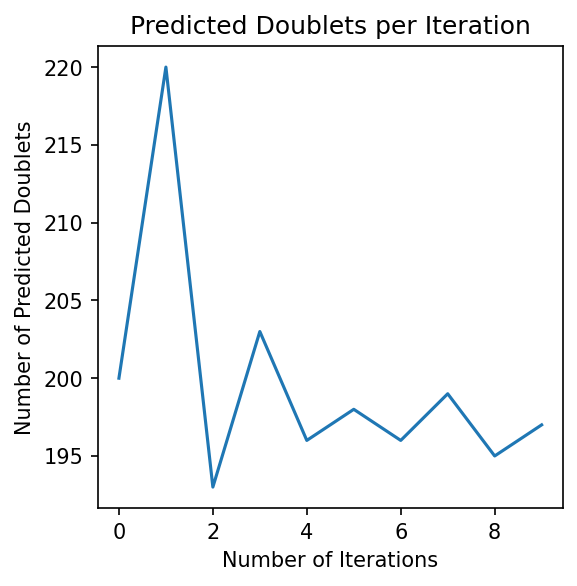

In [8]:
doublets = doubletdetection.plot.convergence(clf, save='convergence_test_PU.pdf', show=True, p_thresh=1e-16, voter_thresh=0.5)


In [9]:
adata

AnnData object with n_obs × n_vars = 29608 × 35539
    obs: 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'is_primary_data', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'Region', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_counts', 'n_genes', 'doublet', 'doublet_score'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo

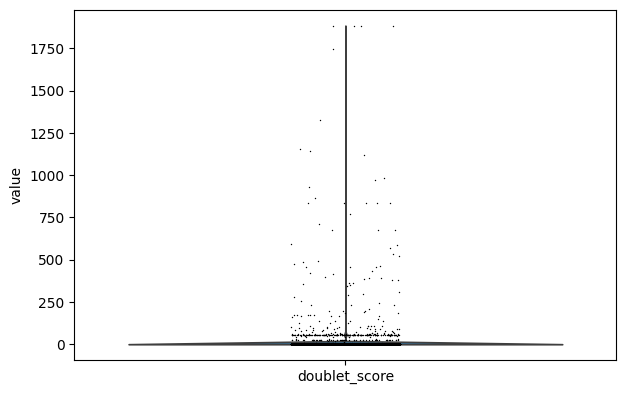

In [10]:
sc.pl.violin(adata, "doublet_score")


In [11]:
adata_singlets = adata[adata.obs['doublet'] == 0].copy()
## Singlets are 0, 1 is doublets


In [12]:
adata_singlets

AnnData object with n_obs × n_vars = 29411 × 35539
    obs: 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'is_primary_data', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'Region', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_counts', 'n_genes', 'doublet', 'doublet_score'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo

In [13]:
adata_singlets.obs.drop(columns=['doublet', 'doublet_score'], inplace=True)
adata_singlets.write_h5ad("PU_singlet.h5ad", compression = 'gzip')